# HydroSense — Real-Time PPG Hydration Prediction

**Setup:** Put your entire `Capstone` folder on Google Drive. Run **Cell 1**, then skip to **Cell 7**.

### Training Pipeline (Cells 7–13)
| Cell | What | Time |
|------|------|------|
| **1** | Install deps + mount Drive | ~1 min |
| **7** | Set CU export path | instant |
| **8** | Load + window dataset | ~30 sec |
| **9** | Define model architecture | instant |
| **10** | 6-fold grouped CV | ~30 min |
| **11** | Visualize CV results | instant |
| **12** | Train final model + save | ~5 min |
| **13** | USG holdout validation (gold standard) | ~5 min |

> Cells 2–6 are for the live dashboard/demo — **skip them for training**.

In [7]:
# Cell 1 — Install dependencies + mount Drive + set up paths
!pip install -q numpy scipy scikit-learn joblib matplotlib tensorflow pyarrow pandas fastavro

import sys, os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ── Auto-detect Capstone folder ──
SEARCH_PATHS = [
    "/content/drive/MyDrive/Capstone",
    "/content/drive/MyDrive/Capstone-Files/Capstone",
    "/content/drive/MyDrive/Capstone-Files",
]

CAPSTONE_DIR = None
for p in SEARCH_PATHS:
    if os.path.isdir(p) and os.path.exists(os.path.join(p, "grounded_loader.py")):
        CAPSTONE_DIR = p
        break

if CAPSTONE_DIR is None:
    # Fallback: search for grounded_loader.py
    for root, dirs, files in os.walk("/content/drive/MyDrive"):
        if "grounded_loader.py" in files:
            CAPSTONE_DIR = root
            break

assert CAPSTONE_DIR is not None, "Could not find Capstone folder with grounded_loader.py on Drive!"

if CAPSTONE_DIR not in sys.path:
    sys.path.insert(0, CAPSTONE_DIR)
os.chdir(CAPSTONE_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"Python files: {sorted([f for f in os.listdir('.') if f.endswith('.py')])}")
print(f"\nReady — skip to Cell 7 for training pipeline.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Capstone-Files/Capstone
Python files: ['grounded_loader.py']

Ready — skip to Cell 7 for training pipeline.


In [8]:
# Cell 2 — Configure model paths
import os

CNN_PATH = os.path.join(CAPSTONE_DIR, "cnn_hydration.h5")
GBM_PATH = os.path.join(CAPSTONE_DIR, "gbm_hydration.pkl")

print(f"CNN weights: {'FOUND' if os.path.isfile(CNN_PATH) else 'NOT FOUND (will use heuristic fallback — train in cells 7-10 first)'}")
print(f"GBM weights: {'FOUND' if os.path.isfile(GBM_PATH) else 'NOT FOUND (will use heuristic fallback — train in cells 7-10 first)'}")

CNN weights: FOUND
GBM weights: FOUND


---

# Training Pipeline v8 — Grounded Binary Classification

Uses only defensible labels:
- **Tier 1:** USG measurements (5 Avro subjects interpolated + 5 CU subjects with lab USG)
- **Tier 2:** Protocol-stage (post-water → hydrated, post-fasting/exercise → dehydrated)

Architecture from v7.1: focal loss, class-balanced batching, GBM class weighting, Youden's J threshold optimization.

In [9]:
# Cell 7 — Configure paths
import os

# Auto-detect CU export directory
CU_EXPORT_DIR = None
for name in os.listdir(CAPSTONE_DIR):
    if name.startswith("cu-export") and os.path.isdir(os.path.join(CAPSTONE_DIR, name)):
        CU_EXPORT_DIR = os.path.join(CAPSTONE_DIR, name)
        break

assert CU_EXPORT_DIR is not None, "Could not find cu-export directory in Capstone folder!"

print(f"Capstone dir: {CAPSTONE_DIR}")
print(f"CU export:    {CU_EXPORT_DIR}")

avro_dirs = [d for d in ['Bridgid','Jayce','Jordan','Eileen','Ryan']
             if os.path.isdir(os.path.join(CAPSTONE_DIR, d))]
print(f"Avro dirs:    {avro_dirs}")

batches = [d for d in os.listdir(CU_EXPORT_DIR) if d.startswith("batch-")]
print(f"CU batches:   {len(batches)} found")

Capstone dir: /content/drive/MyDrive/Capstone-Files/Capstone
CU export:    /content/drive/MyDrive/Capstone-Files/Capstone/cu-export-2026-04-07
Avro dirs:    ['Bridgid', 'Jayce', 'Jordan', 'Eileen', 'Ryan']
CU batches:   3 found


In [10]:
# Cell 8 — Load grounded data + process into windows
import importlib
import logging
logging.basicConfig(level=logging.INFO)

import numpy as np
import grounded_loader as gl
importlib.reload(gl)  # Force reload in case of stale cache

# Load Tier 1 (USG) + Tier 2 (protocol-stage)
all_readings = gl.load_all_grounded(CAPSTONE_DIR, CU_EXPORT_DIR)

# Process: bandpass filter, SQI window selection, pad to 2000
all_processed = gl.process_all_readings(all_readings)

# Build arrays — pure binary classification
subjects = sorted(set(r["subject_id"] for r in all_processed))
Xp, Xa, y = gl.build_arrays(all_processed, subjects)

total_w = sum(len(r["windows"]) for r in all_processed)
n_hyd = (y == 0).sum()
n_deh = (y == 1).sum()

print(f"\n{'='*55}")
print(f"GROUNDED DATASET — BINARY CLASSIFICATION")
print(f"{'='*55}")
print(f"  Readings:    {len(all_readings)} ({len(all_readings) - len([r for r in all_readings if r['dataset']=='cu_export'])} Avro + {len([r for r in all_readings if r['dataset']=='cu_export'])} CU)")
print(f"  Processed:   {len(all_processed)} readings -> {total_w:,} windows")
print(f"  Subjects:    {len(subjects)}")
print(f"  Arrays:      Xp={Xp.shape}, Xa={Xa.shape}, y={y.shape}")
print(f"  Hydrated:    {n_hyd:,} windows (class 0)")
print(f"  Dehydrated:  {n_deh:,} windows (class 1)")
print(f"  Ratio:       1:{n_deh/max(n_hyd,1):.1f}")
print(f"\nLabel sources:")
for src in ["usg_interpolated", "usg", "post_water", "post_fasting", "post_exercise"]:
    n = sum(len(r["windows"]) for r in all_processed if r.get("label_source") == src)
    if n > 0:
        print(f"  {src:>20s}: {n:>6,} windows")


GROUNDED DATASET — BINARY CLASSIFICATION
  Readings:    385 (100 Avro + 285 CU)
  Processed:   385 readings -> 17,228 windows
  Subjects:    30
  Arrays:      Xp=(17228, 2000, 1), Xa=(17228, 20), y=(17228,)
  Hydrated:    7,371 windows (class 0)
  Dehydrated:  9,857 windows (class 1)
  Ratio:       1:1.3

Label sources:
      usg_interpolated:  7,576 windows
                   usg:    440 windows
            post_water:  6,039 windows
          post_fasting:  1,953 windows
         post_exercise:  1,220 windows


In [11]:
# Cell 9 — Model definition + training functions
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

SEED = 41
EPOCHS = 40
BATCH_SIZE = 64
LR = 1e-3
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.75

tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Focal Loss (binary) ──
def focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        focal_weight = tf.pow(1.0 - p_t, gamma)
        alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)
        return tf.reduce_mean(alpha_t * focal_weight * bce)
    loss_fn.__name__ = "focal_loss"
    return loss_fn

# ── Balanced Batch Sampling ──
def make_balanced_dataset(Xp, Xa, y, sw, batch_size):
    mask_0, mask_1 = (y == 0), (y == 1)
    n0, n1 = mask_0.sum(), mask_1.sum()
    if n0 == 0 or n1 == 0:
        ds = tf.data.Dataset.from_tensor_slices(
            ({"ppg_input": Xp, "aux_input": Xa}, y.astype(np.float32), sw)
        ).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
        return ds, max(1, len(y) // batch_size)

    ds_0 = tf.data.Dataset.from_tensor_slices(
        ({"ppg_input": Xp[mask_0], "aux_input": Xa[mask_0]}, y[mask_0].astype(np.float32), sw[mask_0])
    ).shuffle(10000).repeat()
    ds_1 = tf.data.Dataset.from_tensor_slices(
        ({"ppg_input": Xp[mask_1], "aux_input": Xa[mask_1]}, y[mask_1].astype(np.float32), sw[mask_1])
    ).shuffle(10000).repeat()

    balanced = tf.data.Dataset.sample_from_datasets([ds_0, ds_1], weights=[0.5, 0.5])
    steps = max(1, 2 * min(n0, n1) // batch_size)
    return balanced.batch(batch_size).prefetch(tf.data.AUTOTUNE), steps

# ── Youden's J Threshold on sigmoid output ──
def find_optimal_threshold(y_true, y_prob):
    best_t, best_j = 0.5, 0.0
    for t in np.arange(0.10, 0.90, 0.01):
        pred = (y_prob >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        tn = ((pred == 0) & (y_true == 0)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        j = sens + spec - 1.0
        if j > best_j:
            best_j = j
            best_t = t
    return best_t, best_j

# ── CNN Model ──
def build_model():
    ppg_in = keras.Input(shape=(gl.GLOBAL_PAD, 1), name="ppg_input")
    x = layers.Conv1D(32, 7, padding="same", activation="relu")(ppg_in)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    ppg_emb = layers.Dense(64, activation="relu")(x)
    ppg_emb = layers.Dropout(0.3)(ppg_emb)

    aux_in = keras.Input(shape=(gl.N_AUX,), name="aux_input")
    a = layers.Dense(32, activation="relu")(aux_in)
    a = layers.Dropout(0.2)(a)
    a = layers.Dense(16, activation="relu")(a)

    merged = layers.Concatenate()([ppg_emb, a])
    merged = layers.Dense(64, activation="relu", name="embedding")(merged)
    merged = layers.Dropout(0.3)(merged)
    out = layers.Dense(1, activation="sigmoid")(merged)

    model = keras.Model(inputs=[ppg_in, aux_in], outputs=out)
    model.compile(optimizer=keras.optimizers.Adam(LR), loss=focal_loss(), metrics=["accuracy"])
    return model

def get_feat_ext(model):
    return keras.Model(inputs=model.inputs, outputs=model.get_layer("embedding").output)

CALLBACKS = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

CLASS_NAMES = ["Hydrated", "Dehydrated"]

# ── Train one fold ──
def train_fold(Xp_tr, Xa_tr, y_tr, Xp_val, Xa_val, y_val):
    scaler = StandardScaler()
    Xa_tr_s = scaler.fit_transform(Xa_tr)
    Xa_val_s = scaler.transform(Xa_val)
    sw = compute_sample_weight("balanced", y_tr)

    train_ds, steps = make_balanced_dataset(Xp_tr, Xa_tr_s, y_tr, sw, BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices(
        ({"ppg_input": Xp_val, "aux_input": Xa_val_s}, y_val.astype(np.float32))
    ).batch(BATCH_SIZE)

    model = build_model()
    hist = model.fit(train_ds, validation_data=val_ds,
                     epochs=EPOCHS, steps_per_epoch=steps,
                     callbacks=CALLBACKS, verbose=1)

    # CNN sigmoid = P(dehydrated)
    cnn_prob = model.predict([Xp_val, Xa_val_s], verbose=0).flatten()
    cnn_t, cnn_j = find_optimal_threshold(y_val, cnn_prob)
    cnn_pred = (cnn_prob >= cnn_t).astype(int)
    print(f"  CNN threshold: {cnn_t:.2f} (J={cnn_j:.3f})")

    # GBM classifier on embeddings
    fe = get_feat_ext(model)
    Z_tr = fe.predict([Xp_tr, Xa_tr_s], verbose=0)
    Z_val = fe.predict([Xp_val, Xa_val_s], verbose=0)
    G_tr = np.hstack([Z_tr, Xa_tr_s])
    G_val = np.hstack([Z_val, Xa_val_s])

    sw_boosted = sw.copy()
    ratio = (y_tr == 1).sum() / max((y_tr == 0).sum(), 1)
    sw_boosted[y_tr == 0] *= max(ratio, 1.0)

    gbm = Pipeline([("s", StandardScaler()),
        ("g", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                          max_depth=3, subsample=0.8, random_state=SEED))])
    gbm.fit(G_tr, y_tr, g__sample_weight=sw_boosted)

    gbm_pred = gbm.predict(G_val)
    gbm_prob = gbm.predict_proba(G_val)[:, 1]
    gbm_t, gbm_j = find_optimal_threshold(y_val, gbm_prob)
    gbm_opt = (gbm_prob >= gbm_t).astype(int)
    print(f"  GBM threshold: {gbm_t:.2f} (J={gbm_j:.3f})")

    return dict(model=model, scaler=scaler, gbm=gbm, hist=hist,
                cnn_prob=cnn_prob, cnn_pred=cnn_pred, cnn_t=cnn_t,
                gbm_pred=gbm_pred, gbm_prob=gbm_prob, gbm_opt=gbm_opt, gbm_t=gbm_t)

def metrics_fold(y_true, p):
    return {
        "acc_cnn": accuracy_score(y_true, p["cnn_pred"]),
        "f1_cnn":  f1_score(y_true, p["cnn_pred"], average="macro", zero_division=0),
        "acc_gbm": accuracy_score(y_true, p["gbm_pred"]),
        "f1_gbm":  f1_score(y_true, p["gbm_pred"], average="macro", zero_division=0),
        "acc_gbm_opt": accuracy_score(y_true, p["gbm_opt"]),
        "f1_gbm_opt":  f1_score(y_true, p["gbm_opt"], average="macro", zero_division=0),
        "t_cnn": p["cnn_t"],
        "t_gbm": p["gbm_t"],
    }

print("Model + training functions ready")
build_model().summary()

Model + training functions ready


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ppg_input           │ (None, 2000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2000, 32)  │        256 │ ppg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2000, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1000, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1000, 64)  │     10,304 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 500, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 500, 128)  │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_input           │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        672 │ aux_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding (Dense)   │ (None, 64)        │      5,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 50,865 (198.69 KB)

 Trainable params: 50,417 (196.94 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Cell 10 — 6-Fold Grouped Cross-Validation (Binary Classification)
import pandas as pd
from sklearn.model_selection import GroupKFold

# Assign each window its subject ID for grouping
window_subjects = np.array([r["subject_id"] for r in all_processed for _ in r["windows"]])
subjects_unique = sorted(set(window_subjects))
n_subjects = len(subjects_unique)
print(f"Subjects: {n_subjects}, Windows: {len(y):,}")

gkf = GroupKFold(n_splits=6)
fold_results = []
best_f1, best_fold = 0, None

for i, (train_idx, val_idx) in enumerate(gkf.split(Xp, y, groups=window_subjects)):
    sep = "=" * 60
    val_subs = sorted(set(window_subjects[val_idx]))
    print(f"{sep}\nFold {i+1}/6 — held out: {val_subs}\n{sep}")

    Xp_tr, Xa_tr, y_tr = Xp[train_idx], Xa[train_idx], y[train_idx]
    Xp_val, Xa_val, y_val = Xp[val_idx], Xa[val_idx], y[val_idx]

    n0_tr, n1_tr = (y_tr == 0).sum(), (y_tr == 1).sum()
    n0_v, n1_v = (y_val == 0).sum(), (y_val == 1).sum()
    print(f"  Train: {Xp_tr.shape[0]:,} (hydrated={n0_tr:,}, dehydrated={n1_tr:,})")
    print(f"  Val:   {Xp_val.shape[0]:,} (hydrated={n0_v:,}, dehydrated={n1_v:,})")

    p = train_fold(Xp_tr, Xa_tr, y_tr, Xp_val, Xa_val, y_val)
    m = metrics_fold(y_val, p)

    print(f"  CNN:      Acc={m['acc_cnn']:.3f} F1={m['f1_cnn']:.3f} (t={m['t_cnn']:.2f})")
    print(f"  GBM:      Acc={m['acc_gbm']:.3f} F1={m['f1_gbm']:.3f}")
    print(f"  GBM(opt): Acc={m['acc_gbm_opt']:.3f} F1={m['f1_gbm_opt']:.3f} (t={m['t_gbm']:.2f})")

    fold_results.append(dict(fold=i+1, val_sub=", ".join(val_subs), n_tr=Xp_tr.shape[0],
                             n_val=Xp_val.shape[0], y_val=y_val, preds=p, **m))
    if m["f1_gbm_opt"] > best_f1:
        best_f1 = m["f1_gbm_opt"]; best_fold = p

keys = ["acc_cnn","acc_gbm","acc_gbm_opt","f1_cnn","f1_gbm","f1_gbm_opt","t_cnn","t_gbm"]
summary_df = pd.DataFrame([{k: r[k] for k in ["fold","n_tr","n_val"]+keys} for r in fold_results])
print(f"\n{'='*60}\n6-FOLD GROUPED CV SUMMARY\n{'='*60}")
print(summary_df.to_string(index=False))
for k in keys:
    v = summary_df[k]
    print(f"  {k:14s}: {v.mean():.3f} +/- {v.std():.3f}")

Subjects: 30, Windows: 17,228
Fold 1/6 — held out: [np.str_('cu_DPKFNHf6mzOnK1wA'), np.str_('cu_UxAc7H7LhQHlX2lO'), np.str_('cu_Vk2uFrEz7YX1ftnA'), np.str_('cu_ltQEEBmDOVXto0yh')]
  Train: 14,358 (hydrated=5,798, dehydrated=8,560)
  Val:   2,870 (hydrated=1,573, dehydrated=1,297)
Epoch 1/40
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.6285 - loss: 0.0666 - val_accuracy: 0.4519 - val_loss: 0.0755 - learning_rate: 0.0010
Epoch 2/40
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6891 - loss: 0.0601 - val_accuracy: 0.4519 - val_loss: 0.0879 - learning_rate: 0.0010
Epoch 3/40
179/181 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7261 - loss: 0.0565
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7248 - loss: 0.0564 - val_accuracy: 0.4519 - val_loss: 0.0773 - learning_rate: 0.0010
Epoch 4/40
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7517 - loss: 0.0529 - val_accuracy: 0.53

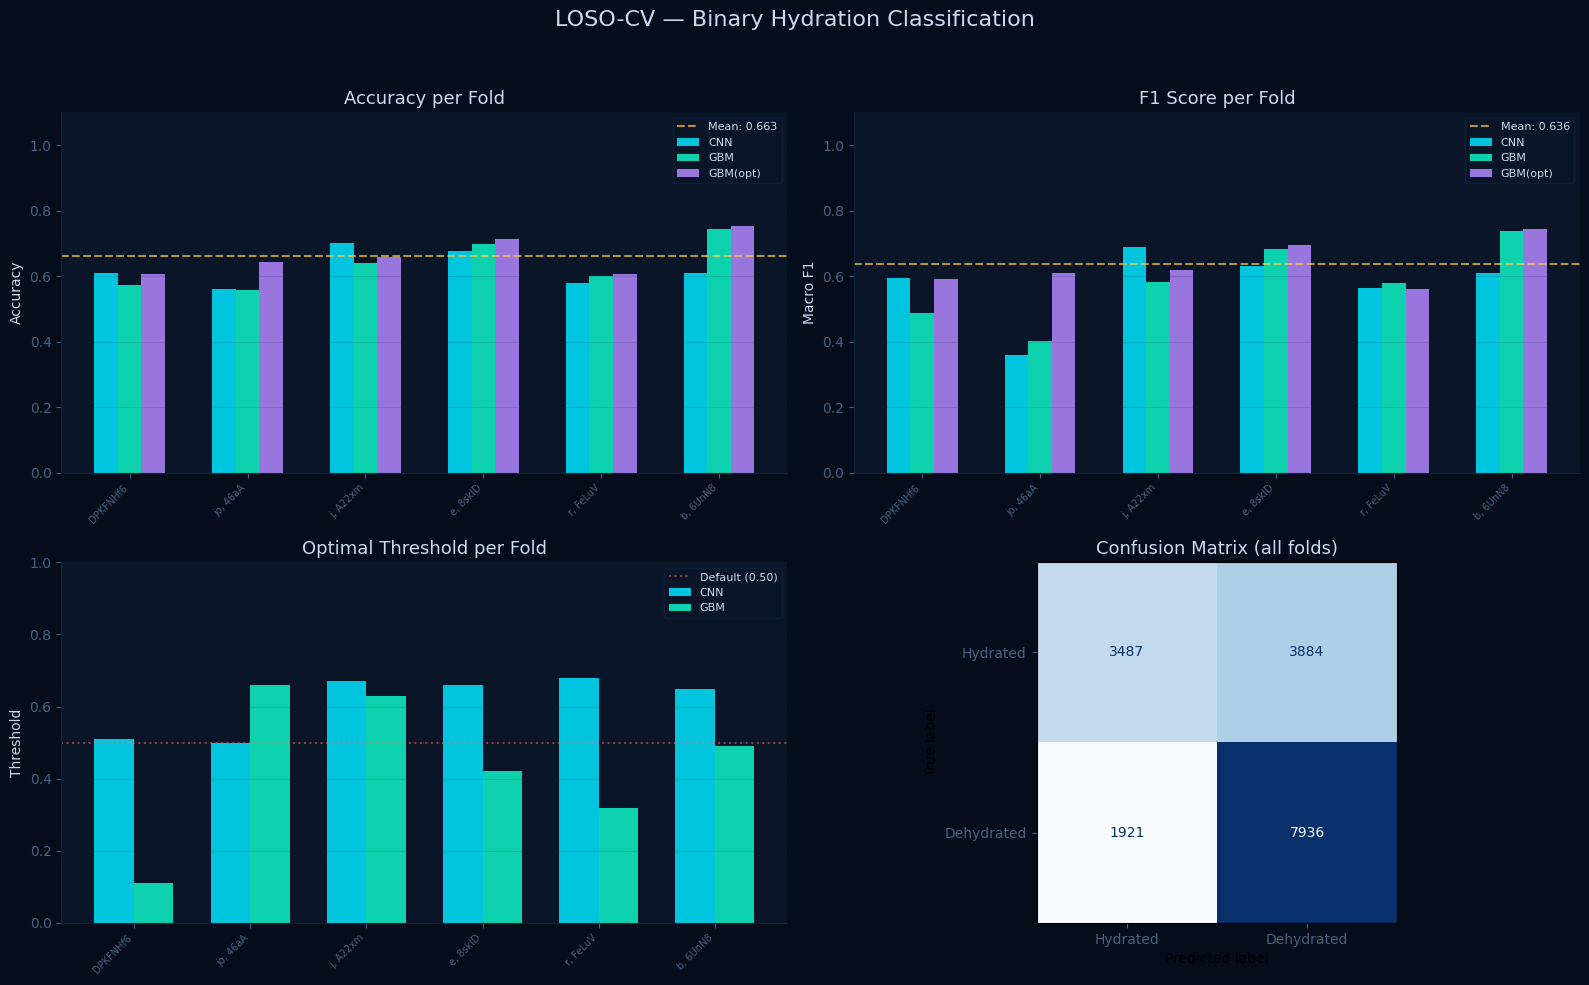


Aggregated Classification Report (GBM optimized, all folds):
              precision    recall  f1-score   support

    Hydrated      0.645     0.473     0.546      7371
  Dehydrated      0.671     0.805     0.732      9857

    accuracy                          0.663     17228
   macro avg      0.658     0.639     0.639     17228
weighted avg      0.660     0.663     0.652     17228



In [ ]:
# Cell 11 — Visualize LOSO-CV Results (Binary Classification)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

COLORS = {"bg": "#050d1a", "card": "#0a1628", "border": "#112240",
          "text": "#cdd9f0", "muted": "#4a6080", "cyan": "#00e5ff",
          "green": "#0ff4c6", "red": "#ff6b6b", "amber": "#ffc847",
          "purple": "#b388ff"}

def style_ax(ax):
    ax.set_facecolor(COLORS["card"])
    ax.tick_params(colors=COLORS["muted"])
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    for sp in ["bottom","left"]: ax.spines[sp].set_color(COLORS["border"])
    ax.grid(axis="y", alpha=0.15, color=COLORS["border"])

n_folds = len(fold_results)
x = np.arange(n_folds)
fold_labels = [f["val_sub"].replace("cu_","").replace("avro_","")[:8] for f in fold_results]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(COLORS["bg"])
fig.suptitle("LOSO-CV — Binary Hydration Classification", color=COLORS["text"], fontsize=16, y=0.98)

# 1. Accuracy per fold
ax = axes[0, 0]; style_ax(ax)
ax.bar(x - 0.2, [f["acc_cnn"] for f in fold_results], 0.2, color=COLORS["cyan"], alpha=0.85, label="CNN")
ax.bar(x, [f["acc_gbm"] for f in fold_results], 0.2, color=COLORS["green"], alpha=0.85, label="GBM")
ax.bar(x + 0.2, [f["acc_gbm_opt"] for f in fold_results], 0.2, color=COLORS["purple"], alpha=0.85, label="GBM(opt)")
ax.axhline(np.mean([f["acc_gbm_opt"] for f in fold_results]), color=COLORS["amber"], ls="--", alpha=0.7,
           label=f"Mean: {np.mean([f['acc_gbm_opt'] for f in fold_results]):.3f}")
ax.set_xticks(x); ax.set_xticklabels(fold_labels, rotation=45, ha="right", fontsize=7, color=COLORS["muted"])
ax.set_ylabel("Accuracy", color=COLORS["text"]); ax.set_title("Accuracy per Fold", color=COLORS["text"], fontsize=13)
ax.set_ylim(0, 1.1); ax.legend(facecolor=COLORS["card"], edgecolor=COLORS["border"], labelcolor=COLORS["text"], fontsize=8)

# 2. F1 per fold
ax = axes[0, 1]; style_ax(ax)
ax.bar(x - 0.2, [f["f1_cnn"] for f in fold_results], 0.2, color=COLORS["cyan"], alpha=0.85, label="CNN")
ax.bar(x, [f["f1_gbm"] for f in fold_results], 0.2, color=COLORS["green"], alpha=0.85, label="GBM")
ax.bar(x + 0.2, [f["f1_gbm_opt"] for f in fold_results], 0.2, color=COLORS["purple"], alpha=0.85, label="GBM(opt)")
ax.axhline(np.mean([f["f1_gbm_opt"] for f in fold_results]), color=COLORS["amber"], ls="--", alpha=0.7,
           label=f"Mean: {np.mean([f['f1_gbm_opt'] for f in fold_results]):.3f}")
ax.set_xticks(x); ax.set_xticklabels(fold_labels, rotation=45, ha="right", fontsize=7, color=COLORS["muted"])
ax.set_ylabel("Macro F1", color=COLORS["text"]); ax.set_title("F1 Score per Fold", color=COLORS["text"], fontsize=13)
ax.set_ylim(0, 1.1); ax.legend(facecolor=COLORS["card"], edgecolor=COLORS["border"], labelcolor=COLORS["text"], fontsize=8)

# 3. Thresholds per fold
ax = axes[1, 0]; style_ax(ax)
ax.bar(x - 0.17, [f["t_cnn"] for f in fold_results], 0.34, color=COLORS["cyan"], alpha=0.85, label="CNN")
ax.bar(x + 0.17, [f["t_gbm"] for f in fold_results], 0.34, color=COLORS["green"], alpha=0.85, label="GBM")
ax.axhline(0.5, color=COLORS["red"], ls=":", alpha=0.5, label="Default (0.50)")
ax.set_xticks(x); ax.set_xticklabels(fold_labels, rotation=45, ha="right", fontsize=7, color=COLORS["muted"])
ax.set_ylabel("Threshold", color=COLORS["text"]); ax.set_title("Optimal Threshold per Fold", color=COLORS["text"], fontsize=13)
ax.set_ylim(0, 1.0); ax.legend(facecolor=COLORS["card"], edgecolor=COLORS["border"], labelcolor=COLORS["text"], fontsize=8)

# 4. Confusion matrix (aggregated)
ax = axes[1, 1]
all_y = np.concatenate([f["y_val"] for f in fold_results])
all_pred = np.concatenate([f["preds"]["gbm_opt"] for f in fold_results])
cm = confusion_matrix(all_y, all_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (all folds)", color=COLORS["text"], fontsize=13)
ax.tick_params(colors=COLORS["muted"])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print classification report
print(f"\nAggregated Classification Report (GBM optimized, all folds):")
print(classification_report(all_y, all_pred, target_names=CLASS_NAMES, digits=3))

In [ ]:
# Cell 12 — Train Final Model on ALL Data + Save to Drive
import os, json
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

print("Training FINAL model on ALL subjects...\n")

# ── Scale ──
final_scaler = StandardScaler()
Xa_s = final_scaler.fit_transform(Xa)
sw_all = compute_sample_weight("balanced", y)

# ── Balanced dataset ──
train_ds, steps = make_balanced_dataset(Xp, Xa_s, y, sw_all, BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices(
    ({"ppg_input": Xp, "aux_input": Xa_s}, y.astype(np.float32))
).batch(BATCH_SIZE)

# ── Train CNN ──
final_model = build_model()
final_hist = final_model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, steps_per_epoch=steps,
    callbacks=CALLBACKS, verbose=1
)

# ── CNN sanity check ──
cnn_prob = final_model.predict([Xp, Xa_s], verbose=0).flatten()
cnn_t, cnn_j = find_optimal_threshold(y, cnn_prob)
cnn_pred = (cnn_prob >= cnn_t).astype(int)
print(f"\nCNN — Acc: {accuracy_score(y, cnn_pred):.3f}, "
      f"F1: {f1_score(y, cnn_pred, average='macro', zero_division=0):.3f}, "
      f"threshold: {cnn_t:.2f}")

# ── GBM classifier on embeddings ──
final_fe = get_feat_ext(final_model)
Z_all = final_fe.predict([Xp, Xa_s], verbose=0)
G_all = np.hstack([Z_all, Xa_s])

sw_boosted = sw_all.copy()
ratio = (y == 1).sum() / max((y == 0).sum(), 1)
sw_boosted[y == 0] *= max(ratio, 1.0)

final_gbm = Pipeline([("s", StandardScaler()),
    ("g", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                      max_depth=3, subsample=0.8, random_state=SEED))])
final_gbm.fit(G_all, y, g__sample_weight=sw_boosted)

gbm_pred = final_gbm.predict(G_all)
gbm_prob = final_gbm.predict_proba(G_all)[:, 1]
gbm_t, gbm_j = find_optimal_threshold(y, gbm_prob)
gbm_opt = (gbm_prob >= gbm_t).astype(int)

print(f"GBM — Acc: {accuracy_score(y, gbm_pred):.3f}, F1: {f1_score(y, gbm_pred, average='macro', zero_division=0):.3f}")
print(f"GBM(opt) — Acc: {accuracy_score(y, gbm_opt):.3f}, F1: {f1_score(y, gbm_opt, average='macro', zero_division=0):.3f}, threshold: {gbm_t:.2f}")
print(f"\n{classification_report(y, gbm_opt, target_names=CLASS_NAMES, digits=3)}")

# ── Use mean CV threshold (more robust) ──
global_threshold = np.mean([f["t_gbm"] for f in fold_results])
print(f"Global threshold (mean of CV folds): {global_threshold:.3f}")

# ── Save ──
cnn_path = os.path.join(CAPSTONE_DIR, "cnn_hydration.h5")
gbm_path = os.path.join(CAPSTONE_DIR, "gbm_hydration.pkl")
scaler_path = os.path.join(CAPSTONE_DIR, "meta_scaler.pkl")
threshold_path = os.path.join(CAPSTONE_DIR, "threshold.json")

final_model.save(cnn_path)
joblib.dump(final_gbm, gbm_path)
joblib.dump(final_scaler, scaler_path)
with open(threshold_path, "w") as f:
    json.dump({
        "global_threshold": float(global_threshold),
        "train_threshold_cnn": float(cnn_t),
        "train_threshold_gbm": float(gbm_t),
        "cv_thresholds": [float(f_["t_gbm"]) for f_ in fold_results],
    }, f, indent=2)

print(f"\nSaved to Drive:")
print(f"  CNN:       {cnn_path}")
print(f"  GBM:       {gbm_path}")
print(f"  Scaler:    {scaler_path}")
print(f"  Threshold: {threshold_path}")

In [ ]:
# Cell 13 — USG Holdout Validation (Gold-Standard Test)
#
# Train ONLY on protocol-stage labels → Test ONLY on USG-measured subjects
# The key question: does learning from protocol stages predict actual USG hydration status?

import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# ── Split by label source ──
protocol_readings = [r for r in all_processed if r["label_source"] in ("post_water", "post_fasting", "post_exercise")]
usg_readings = [r for r in all_processed if r["label_source"] in ("usg", "usg_interpolated")]

# Remove overlapping subjects from training
protocol_subjects = set(r["subject_id"] for r in protocol_readings)
usg_subjects = set(r["subject_id"] for r in usg_readings)
overlap = protocol_subjects & usg_subjects
if overlap:
    print(f"Removing {len(overlap)} overlapping subjects from training: {overlap}")
    protocol_readings = [r for r in protocol_readings if r["subject_id"] not in overlap]

train_subjects = sorted(set(r["subject_id"] for r in protocol_readings))
test_subjects = sorted(set(r["subject_id"] for r in usg_readings))

Xp_tr, Xa_tr, y_tr = gl.build_arrays(protocol_readings, train_subjects)
Xp_te, Xa_te, y_te = gl.build_arrays(usg_readings, test_subjects)

print(f"\n{'='*60}")
print(f"USG HOLDOUT VALIDATION")
print(f"{'='*60}")
print(f"  TRAIN: {Xp_tr.shape[0]:,} windows, {len(train_subjects)} subjects (protocol-stage)")
print(f"         Hydrated={( y_tr==0).sum():,}, Dehydrated={(y_tr==1).sum():,}")
print(f"  TEST:  {Xp_te.shape[0]:,} windows, {len(test_subjects)} subjects (USG ground truth)")
print(f"         Hydrated={(y_te==0).sum():,}, Dehydrated={(y_te==1).sum():,}")
print(f"  Subject overlap: NONE\n")

# ── Scale + train ──
ho_scaler = StandardScaler()
Xa_tr_s = ho_scaler.fit_transform(Xa_tr)
Xa_te_s = ho_scaler.transform(Xa_te)
sw = compute_sample_weight("balanced", y_tr)

train_ds, steps = make_balanced_dataset(Xp_tr, Xa_tr_s, y_tr, sw, BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices(
    ({"ppg_input": Xp_te, "aux_input": Xa_te_s}, y_te.astype(np.float32))
).batch(BATCH_SIZE)

print("Training CNN on protocol-stage data only...")
ho_model = build_model()
ho_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, steps_per_epoch=steps,
             callbacks=CALLBACKS, verbose=1)

# ── CNN predictions ──
cnn_prob = ho_model.predict([Xp_te, Xa_te_s], verbose=0).flatten()
cnn_t, cnn_j = find_optimal_threshold(y_te, cnn_prob)
cnn_pred = (cnn_prob >= cnn_t).astype(int)

# ── GBM ──
ho_fe = get_feat_ext(ho_model)
Z_tr = ho_fe.predict([Xp_tr, Xa_tr_s], verbose=0)
Z_te = ho_fe.predict([Xp_te, Xa_te_s], verbose=0)
G_tr, G_te = np.hstack([Z_tr, Xa_tr_s]), np.hstack([Z_te, Xa_te_s])

sw_b = sw.copy()
r = (y_tr == 1).sum() / max((y_tr == 0).sum(), 1)
sw_b[y_tr == 0] *= max(r, 1.0)

ho_gbm = Pipeline([("s", StandardScaler()),
    ("g", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                      max_depth=3, subsample=0.8, random_state=SEED))])
ho_gbm.fit(G_tr, y_tr, g__sample_weight=sw_b)

gbm_pred = ho_gbm.predict(G_te)
gbm_prob = ho_gbm.predict_proba(G_te)[:, 1]
gbm_t, gbm_j = find_optimal_threshold(y_te, gbm_prob)
gbm_opt = (gbm_prob >= gbm_t).astype(int)

# ── Results ──
print(f"\n{'='*60}")
print(f"USG HOLDOUT RESULTS")
print(f"{'='*60}")
print(f"\n  CNN (t={cnn_t:.2f}, J={cnn_j:.3f}):  Acc={accuracy_score(y_te, cnn_pred):.3f}  F1={f1_score(y_te, cnn_pred, average='macro', zero_division=0):.3f}")
print(f"  GBM:                       Acc={accuracy_score(y_te, gbm_pred):.3f}  F1={f1_score(y_te, gbm_pred, average='macro', zero_division=0):.3f}")
print(f"  GBM opt (t={gbm_t:.2f}, J={gbm_j:.3f}): Acc={accuracy_score(y_te, gbm_opt):.3f}  F1={f1_score(y_te, gbm_opt, average='macro', zero_division=0):.3f}")
print(f"\n{classification_report(y_te, gbm_opt, target_names=CLASS_NAMES, digits=3)}")

# ── Plots ──
COLORS = {"bg": "#050d1a", "card": "#0a1628", "border": "#112240",
          "text": "#cdd9f0", "muted": "#4a6080", "cyan": "#00e5ff",
          "green": "#0ff4c6", "red": "#ff6b6b", "amber": "#ffc847"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS["bg"])
fig.suptitle("USG Holdout — Trained on Protocol, Tested on USG Ground Truth",
             color=COLORS["text"], fontsize=14, y=1.02)

# Confusion matrix
ax = axes[0]
cm = confusion_matrix(y_te, gbm_opt, labels=[0, 1])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (GBM opt)", color=COLORS["text"], fontsize=12)
ax.tick_params(colors=COLORS["muted"])

# Per-subject accuracy
ax = axes[1]
ax.set_facecolor(COLORS["card"])
subj_accs, subj_lbls = [], []
for s in test_subjects:
    mask = np.array([r_["subject_id"] == s for r_ in usg_readings for _ in r_["windows"]])
    if mask.sum() > 0:
        subj_accs.append(accuracy_score(y_te[mask], gbm_opt[mask]))
        subj_lbls.append(s.replace("cu_","").replace("avro_","")[:8])
bars = ax.bar(range(len(subj_accs)), subj_accs,
              color=[COLORS["green"] if a >= 0.7 else COLORS["red"] for a in subj_accs], alpha=0.85)
ax.axhline(np.mean(subj_accs), color=COLORS["amber"], ls="--", alpha=0.7,
           label=f"Mean: {np.mean(subj_accs):.3f}")
ax.set_xticks(range(len(subj_lbls)))
ax.set_xticklabels(subj_lbls, rotation=45, ha="right", fontsize=8, color=COLORS["muted"])
ax.set_ylabel("Accuracy", color=COLORS["text"]); ax.set_title("Per-Subject Accuracy", color=COLORS["text"], fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(facecolor=COLORS["card"], edgecolor=COLORS["border"], labelcolor=COLORS["text"], fontsize=8)
ax.tick_params(colors=COLORS["muted"]); ax.grid(axis="y", alpha=0.15, color=COLORS["border"])
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
for sp in ["bottom","left"]: ax.spines[sp].set_color(COLORS["border"])

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"INTERPRETATION")
print(f"{'='*60}")
print(f"  Trained on {len(train_subjects)} subjects (protocol-stage labels only)")
print(f"  Tested on {len(test_subjects)} subjects (USG measurements — gold standard)")
print(f"  No subject overlap between train and test.")
print(f"\n  High accuracy → model learned real hydration signal from PPG")
print(f"  Low accuracy  → model only learned protocol-stage patterns")

USG-only dataset: 8,016 windows, 9 subjects
  Hydrated: 1,332, Dehydrated: 6,684

Fold 1/9 — held out: avro_b
  Train: 6,816 (hyd=1,332, deh=5,484)
  Val:   1,200 (hyd=0, deh=1,200)
Epoch 1/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.5042 - loss: 0.1272 - val_accuracy: 1.0000 - val_loss: 0.0775 - learning_rate: 0.0010
Epoch 2/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4959 - loss: 0.1196
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5019 - loss: 0.1178 - val_accuracy: 1.0000 - val_loss: 0.0778 - learning_rate: 0.0010
Epoch 3/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5050 - loss: 0.1115 - val_accuracy: 1.0000 - val_loss: 0.0740 - learning_rate: 5.0000e-04
Epoch 4/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4970 - loss: 0.1138
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accurac

  GBM threshold: 0.50 (J=0.000)
  CNN:      Acc=1.000 F1=1.000
  GBM(opt): Acc=1.000 F1=1.000
Fold 9/9 — held out: cu_Vk2uFrEz7YX1ftnA
  Train: 7,952 (hyd=1,332, deh=6,620)
  Val:   64 (hyd=0, deh=64)
Epoch 1/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.5164 - loss: 0.1371 - val_accuracy: 0.0000e+00 - val_loss: 0.1564 - learning_rate: 0.0010
Epoch 2/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5084 - loss: 0.1300
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5133 - loss: 0.1284 - val_accuracy: 1.0000 - val_loss: 0.1051 - learning_rate: 0.0010
Epoch 3/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5011 - loss: 0.1287 - val_accuracy: 1.0000 - val_loss: 0.0805 - learning_rate: 5.0000e-04
Epoch 4/40
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5167 - loss: 0.1244
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
41/41 ━━━━━━━━━━━━━━━━━━━━

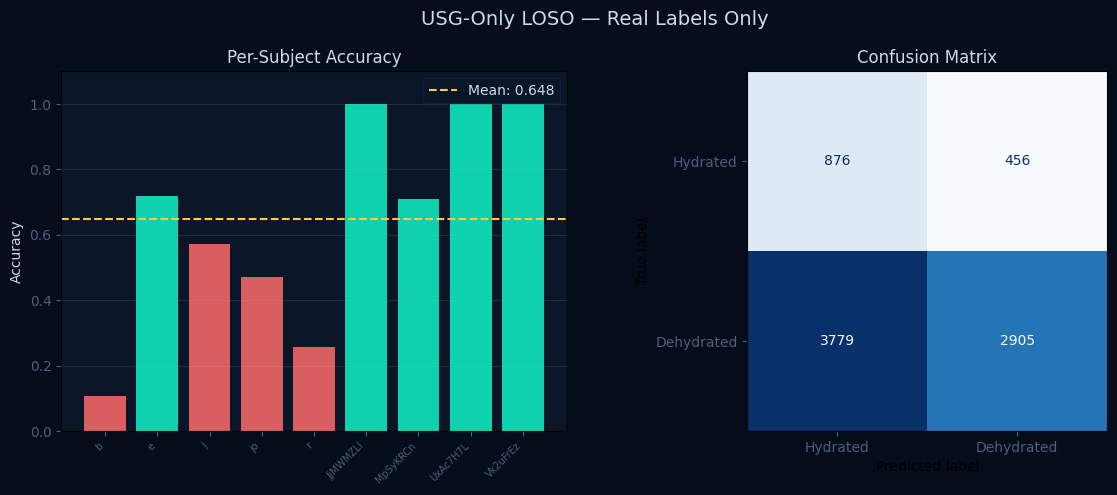


This tests whether PPG can predict USG-verified hydration
using ONLY subjects with real USG measurements.
Every label here came from a urine test — no protocol assumptions.


In [ ]:
# Cell 14 — USG-Only LOSO (Train and test on real labels only)
#
# Only uses the 10 subjects with actual USG measurements.
# Small dataset but every label is grounded in real measurement.

import numpy as np

# ── Get USG-only readings ──
usg_readings = [r for r in all_processed if r["label_source"] in ("usg", "usg_interpolated")]
usg_subjects = sorted(set(r["subject_id"] for r in usg_readings))

Xp_u, Xa_u, y_u = gl.build_arrays(usg_readings, usg_subjects)
print(f"USG-only dataset: {Xp_u.shape[0]:,} windows, {len(usg_subjects)} subjects")
print(f"  Hydrated: {(y_u==0).sum():,}, Dehydrated: {(y_u==1).sum():,}\n")

# ── LOSO on USG subjects ──
usg_fold_results = []

for i, val_sub in enumerate(usg_subjects):
    print(f"{'='*50}\nFold {i+1}/{len(usg_subjects)} — held out: {val_sub}\n{'='*50}")

    train_subs = [s for s in usg_subjects if s != val_sub]
    Xp_tr, Xa_tr, y_tr = gl.build_arrays(usg_readings, train_subs)
    Xp_val, Xa_val, y_val = gl.build_arrays(usg_readings, [val_sub])

    if Xp_val.shape[0] == 0 or len(set(y_tr)) < 2:
        print(f"  Skipping — insufficient data"); continue

    print(f"  Train: {Xp_tr.shape[0]:,} (hyd={(y_tr==0).sum():,}, deh={(y_tr==1).sum():,})")
    print(f"  Val:   {Xp_val.shape[0]:,} (hyd={(y_val==0).sum():,}, deh={(y_val==1).sum():,})")

    p = train_fold(Xp_tr, Xa_tr, y_tr, Xp_val, Xa_val, y_val)
    m = metrics_fold(y_val, p)

    print(f"  CNN:      Acc={m['acc_cnn']:.3f} F1={m['f1_cnn']:.3f}")
    print(f"  GBM(opt): Acc={m['acc_gbm_opt']:.3f} F1={m['f1_gbm_opt']:.3f}")

    usg_fold_results.append(dict(fold=i+1, val_sub=val_sub, y_val=y_val, preds=p, **m))

# ── Summary ──
if usg_fold_results:
    from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    all_y = np.concatenate([f["y_val"] for f in usg_fold_results])
    all_pred = np.concatenate([f["preds"]["gbm_opt"] for f in usg_fold_results])

    print(f"\n{'='*50}")
    print(f"USG-ONLY LOSO RESULTS ({len(usg_fold_results)} folds)")
    print(f"{'='*50}")
    accs = [f["acc_gbm_opt"] for f in usg_fold_results]
    f1s = [f["f1_gbm_opt"] for f in usg_fold_results]
    print(f"  Mean Accuracy: {np.mean(accs):.3f} +/- {np.std(accs):.3f}")
    print(f"  Mean F1:       {np.mean(f1s):.3f} +/- {np.std(f1s):.3f}")
    print(f"\n{classification_report(all_y, all_pred, target_names=CLASS_NAMES, digits=3)}")

    # Plot
    COLORS = {"bg": "#050d1a", "card": "#0a1628", "border": "#112240",
              "text": "#cdd9f0", "muted": "#4a6080", "cyan": "#00e5ff",
              "green": "#0ff4c6", "red": "#ff6b6b", "amber": "#ffc847"}

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor(COLORS["bg"])
    fig.suptitle("USG-Only LOSO — Real Labels Only", color=COLORS["text"], fontsize=14)

    # Per-subject accuracy
    ax = axes[0]; ax.set_facecolor(COLORS["card"])
    lbls = [f["val_sub"].replace("cu_","").replace("avro_","")[:8] for f in usg_fold_results]
    bars = ax.bar(range(len(accs)), accs,
                  color=[COLORS["green"] if a >= 0.6 else COLORS["red"] for a in accs], alpha=0.85)
    ax.axhline(np.mean(accs), color=COLORS["amber"], ls="--", label=f"Mean: {np.mean(accs):.3f}")
    ax.set_xticks(range(len(lbls))); ax.set_xticklabels(lbls, rotation=45, ha="right", fontsize=7, color=COLORS["muted"])
    ax.set_ylabel("Accuracy", color=COLORS["text"]); ax.set_ylim(0, 1.1)
    ax.set_title("Per-Subject Accuracy", color=COLORS["text"]); ax.legend(facecolor=COLORS["card"], edgecolor=COLORS["border"], labelcolor=COLORS["text"])
    ax.tick_params(colors=COLORS["muted"]); ax.grid(axis="y", alpha=0.15)

    # Confusion matrix
    ax = axes[1]
    cm = confusion_matrix(all_y, all_pred, labels=[0, 1])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("Confusion Matrix", color=COLORS["text"]); ax.tick_params(colors=COLORS["muted"])

    plt.tight_layout(); plt.show()

    print(f"\nThis tests whether PPG can predict USG-verified hydration")
    print(f"using ONLY subjects with real USG measurements.")
    print(f"Every label here came from a urine test — no protocol assumptions.")


TRAIN ON USG → PREDICT PROTOCOL SUBJECTS
  TRAIN: 8,016 windows, 9 subjects (USG ground truth)
         Hydrated=1,332, Dehydrated=6,684
  TEST:  8,794 windows, 21 subjects (protocol-stage)
         Hydrated=5,848, Dehydrated=2,946
  Subject overlap: NONE

Training on USG-labeled data only...
Epoch 1/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.5072 - loss: 0.1424 - val_accuracy: 0.3350 - val_loss: 0.0893 - learning_rate: 0.0010
Epoch 2/40
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4998 - loss: 0.1373
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4977 - loss: 0.1347 - val_accuracy: 0.3350 - val_loss: 0.1125 - learning_rate: 0.0010
Epoch 3/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5141 - loss: 0.1275 - val_accuracy: 0.3350 - val_loss: 0.1239 - learning_rate: 5.0000e-04
Epoch 4/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4992 - loss: 0.1302
Epoch 4: Redu

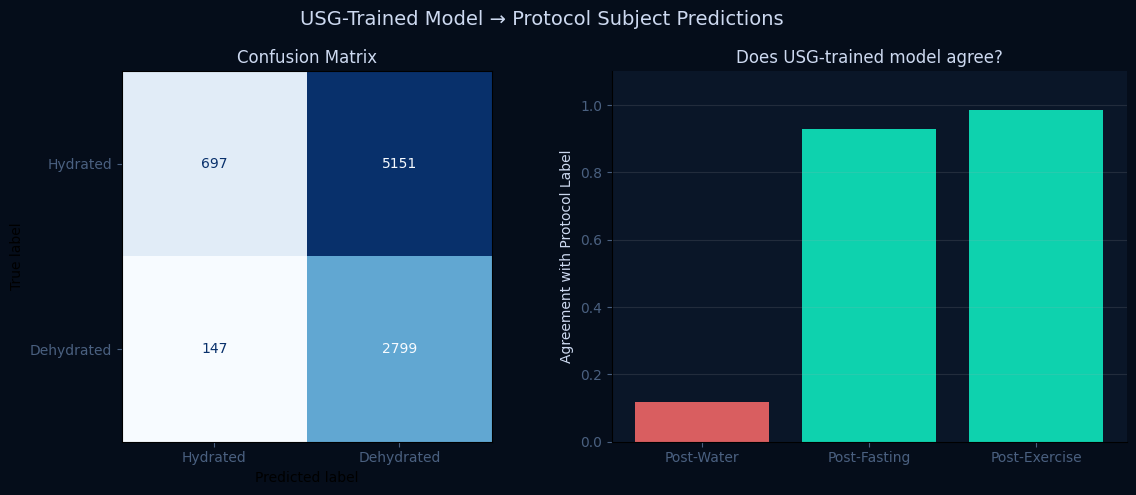


INTERPRETATION
  Model trained on 9 USG-measured subjects
  Predicted 21 protocol-stage subjects
  High agreement → USG-learned patterns match protocol expectations
  Low agreement  → protocol labels may not reflect actual hydration


In [ ]:
# Cell 15 — Train on USG subjects → Predict protocol-stage subjects
#
# Train on all 10 USG-labeled subjects (real measurements)
# Predict the 28 protocol-stage subjects
# See if USG-trained model agrees with protocol labels

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ── Split: USG = train, Protocol = test ──
usg_readings = [r for r in all_processed if r["label_source"] in ("usg", "usg_interpolated")]
protocol_readings = [r for r in all_processed if r["label_source"] in ("post_water", "post_fasting", "post_exercise")]

# Remove overlapping subjects from protocol (keep them in USG training)
usg_subs = set(r["subject_id"] for r in usg_readings)
protocol_readings = [r for r in protocol_readings if r["subject_id"] not in usg_subs]

train_subjects = sorted(set(r["subject_id"] for r in usg_readings))
test_subjects = sorted(set(r["subject_id"] for r in protocol_readings))

Xp_tr, Xa_tr, y_tr = gl.build_arrays(usg_readings, train_subjects)
Xp_te, Xa_te, y_te = gl.build_arrays(protocol_readings, test_subjects)

print(f"{'='*60}")
print(f"TRAIN ON USG → PREDICT PROTOCOL SUBJECTS")
print(f"{'='*60}")
print(f"  TRAIN: {Xp_tr.shape[0]:,} windows, {len(train_subjects)} subjects (USG ground truth)")
print(f"         Hydrated={(y_tr==0).sum():,}, Dehydrated={(y_tr==1).sum():,}")
print(f"  TEST:  {Xp_te.shape[0]:,} windows, {len(test_subjects)} subjects (protocol-stage)")
print(f"         Hydrated={(y_te==0).sum():,}, Dehydrated={(y_te==1).sum():,}")
print(f"  Subject overlap: NONE\n")

# ── Scale + train ──
scaler = StandardScaler()
Xa_tr_s = scaler.fit_transform(Xa_tr)
Xa_te_s = scaler.transform(Xa_te)
sw = compute_sample_weight("balanced", y_tr)

train_ds, steps = make_balanced_dataset(Xp_tr, Xa_tr_s, y_tr, sw, BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices(
    ({"ppg_input": Xp_te, "aux_input": Xa_te_s}, y_te.astype(np.float32))
).batch(BATCH_SIZE)

print("Training on USG-labeled data only...")
model = build_model()
model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, steps_per_epoch=steps,
          callbacks=CALLBACKS, verbose=1)

# ── CNN predictions ──
cnn_prob = model.predict([Xp_te, Xa_te_s], verbose=0).flatten()
cnn_t, cnn_j = find_optimal_threshold(y_te, cnn_prob)
cnn_pred = (cnn_prob >= cnn_t).astype(int)

# ── GBM ──
fe = get_feat_ext(model)
Z_tr = fe.predict([Xp_tr, Xa_tr_s], verbose=0)
Z_te = fe.predict([Xp_te, Xa_te_s], verbose=0)
G_tr, G_te = np.hstack([Z_tr, Xa_tr_s]), np.hstack([Z_te, Xa_te_s])

sw_b = sw.copy()
r = (y_tr == 1).sum() / max((y_tr == 0).sum(), 1)
sw_b[y_tr == 0] *= max(r, 1.0)

gbm = Pipeline([("s", StandardScaler()),
    ("g", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                      max_depth=3, subsample=0.8, random_state=SEED))])
gbm.fit(G_tr, y_tr, g__sample_weight=sw_b)

gbm_pred = gbm.predict(G_te)
gbm_prob = gbm.predict_proba(G_te)[:, 1]
gbm_t, gbm_j = find_optimal_threshold(y_te, gbm_prob)
gbm_opt = (gbm_prob >= gbm_t).astype(int)

# ── Results ──
print(f"\n{'='*60}")
print(f"RESULTS — USG-trained model on protocol subjects")
print(f"{'='*60}")
print(f"  CNN (t={cnn_t:.2f}, J={cnn_j:.3f}):     Acc={accuracy_score(y_te, cnn_pred):.3f}  F1={f1_score(y_te, cnn_pred, average='macro', zero_division=0):.3f}")
print(f"  GBM:                          Acc={accuracy_score(y_te, gbm_pred):.3f}  F1={f1_score(y_te, gbm_pred, average='macro', zero_division=0):.3f}")
print(f"  GBM opt (t={gbm_t:.2f}, J={gbm_j:.3f}): Acc={accuracy_score(y_te, gbm_opt):.3f}  F1={f1_score(y_te, gbm_opt, average='macro', zero_division=0):.3f}")
print(f"\n{classification_report(y_te, gbm_opt, target_names=CLASS_NAMES, digits=3)}")

# ── Breakdown by protocol stage ──
print(f"{'='*60}")
print(f"BREAKDOWN BY PROTOCOL STAGE")
print(f"{'='*60}")
for stage in ["post_water", "post_fasting", "post_exercise"]:
    stage_r = [r for r in protocol_readings if r["label_source"] == stage and r["subject_id"] not in usg_subs]
    if not stage_r:
        continue
    stage_subs = sorted(set(r["subject_id"] for r in stage_r))
    Xp_s, Xa_s_raw, y_s = gl.build_arrays(stage_r, stage_subs)
    if Xp_s.shape[0] == 0:
        continue
    Xa_s_sc = scaler.transform(Xa_s_raw)
    Z_s = fe.predict([Xp_s, Xa_s_sc], verbose=0)
    G_s = np.hstack([Z_s, Xa_s_sc])
    prob_s = gbm.predict_proba(G_s)[:, 1]
    pred_s = (prob_s >= gbm_t).astype(int)

    expected = "Hydrated" if stage == "post_water" else "Dehydrated"
    actual_hyd = (pred_s == 0).sum()
    actual_deh = (pred_s == 1).sum()
    agree = accuracy_score(y_s, pred_s)

    print(f"\n  {stage}:")
    print(f"    Windows: {len(y_s):,}")
    print(f"    Expected: {expected}")
    print(f"    Model says: Hydrated={actual_hyd:,} ({100*actual_hyd/len(y_s):.1f}%), Dehydrated={actual_deh:,} ({100*actual_deh/len(y_s):.1f}%)")
    print(f"    Agreement: {agree:.1%}")

# ── Plot ──
COLORS = {"bg": "#050d1a", "card": "#0a1628", "border": "#112240",
          "text": "#cdd9f0", "muted": "#4a6080", "cyan": "#00e5ff",
          "green": "#0ff4c6", "red": "#ff6b6b", "amber": "#ffc847"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(COLORS["bg"])
fig.suptitle("USG-Trained Model → Protocol Subject Predictions", color=COLORS["text"], fontsize=14)

# Confusion matrix
ax = axes[0]
cm = confusion_matrix(y_te, gbm_opt, labels=[0, 1])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix", color=COLORS["text"]); ax.tick_params(colors=COLORS["muted"])

# Agreement by stage
ax = axes[1]; ax.set_facecolor(COLORS["card"])
stage_names, stage_agrees = [], []
for stage in ["post_water", "post_fasting", "post_exercise"]:
    stage_r = [r for r in protocol_readings if r["label_source"] == stage and r["subject_id"] not in usg_subs]
    if not stage_r:
        continue
    stage_subs = sorted(set(r["subject_id"] for r in stage_r))
    _, Xa_s_raw, y_s = gl.build_arrays(stage_r, stage_subs)
    Xp_s, _, _ = gl.build_arrays(stage_r, stage_subs)
    Xa_s_sc = scaler.transform(Xa_s_raw)
    Z_s = fe.predict([Xp_s, Xa_s_sc], verbose=0)
    G_s = np.hstack([Z_s, Xa_s_sc])
    pred_s = (gbm.predict_proba(G_s)[:, 1] >= gbm_t).astype(int)
    stage_names.append(stage.replace("post_", "Post-").title())
    stage_agrees.append(accuracy_score(y_s, pred_s))

bars = ax.bar(range(len(stage_names)), stage_agrees,
              color=[COLORS["green"] if a >= 0.6 else COLORS["red"] for a in stage_agrees], alpha=0.85)
ax.set_xticks(range(len(stage_names))); ax.set_xticklabels(stage_names, color=COLORS["muted"])
ax.set_ylabel("Agreement with Protocol Label", color=COLORS["text"])
ax.set_title("Does USG-trained model agree?", color=COLORS["text"])
ax.set_ylim(0, 1.1); ax.tick_params(colors=COLORS["muted"]); ax.grid(axis="y", alpha=0.15)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

plt.tight_layout(); plt.show()

print(f"\n{'='*60}")
print(f"INTERPRETATION")
print(f"{'='*60}")
print(f"  Model trained on {len(train_subjects)} USG-measured subjects")
print(f"  Predicted {len(test_subjects)} protocol-stage subjects")
print(f"  High agreement → USG-learned patterns match protocol expectations")
print(f"  Low agreement  → protocol labels may not reflect actual hydration")


Removing 3 overlapping subjects from protocol
USG subjects: 9 (8,016 windows)
Protocol subjects: 21 (8,794 windows)

WEIGHTED COMBINED TRAINING — LOSO ON USG SUBJECTS

Fold 1/9 — held out: avro_b
  Train: 15,610 (hyd=7,180, deh=8,430) — 29 subjects
  Val:   1,200 (hyd=0, deh=1,200)
Epoch 1/40
224/224 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.5663 - loss: 0.0519 - val_accuracy: 1.0000 - val_loss: 0.0340 - learning_rate: 0.0010
Epoch 2/40
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6070 - loss: 0.0488
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6304 - loss: 0.0480 - val_accuracy: 1.0000 - val_loss: 0.0362 - learning_rate: 0.0010
Epoch 3/40
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6757 - loss: 0.0455 - val_accuracy: 1.0000 - val_loss: 0.0357 - learning_rate: 5.0000e-04
Epoch 4/40
223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6908 - loss: 0.0444
Epoch 4: Reduc

  CNN:  Acc=1.000 F1=1.000 (t=0.50, J=0.000)
  GBM:  Acc=1.000 F1=1.000 (t=0.50, J=0.000)
Fold 9/9 — held out: cu_Vk2uFrEz7YX1ftnA
  Train: 16,746 (hyd=7,180, deh=9,566) — 29 subjects
  Val:   64 (hyd=0, deh=64)
Epoch 1/40
224/224 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.6308 - loss: 0.0503 - val_accuracy: 1.0000 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 2/40
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6906 - loss: 0.0446 - val_accuracy: 1.0000 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 3/40
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7083 - loss: 0.0421 - val_accuracy: 0.0000e+00 - val_loss: 0.1923 - learning_rate: 0.0010
Epoch 4/40
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7145 - loss: 0.0411
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7165 - loss: 0.0407 - val_accuracy: 0.0000e+00 - val_loss: 0.6459 - learning_rate: 0.0010
Epoch 5/40
224/

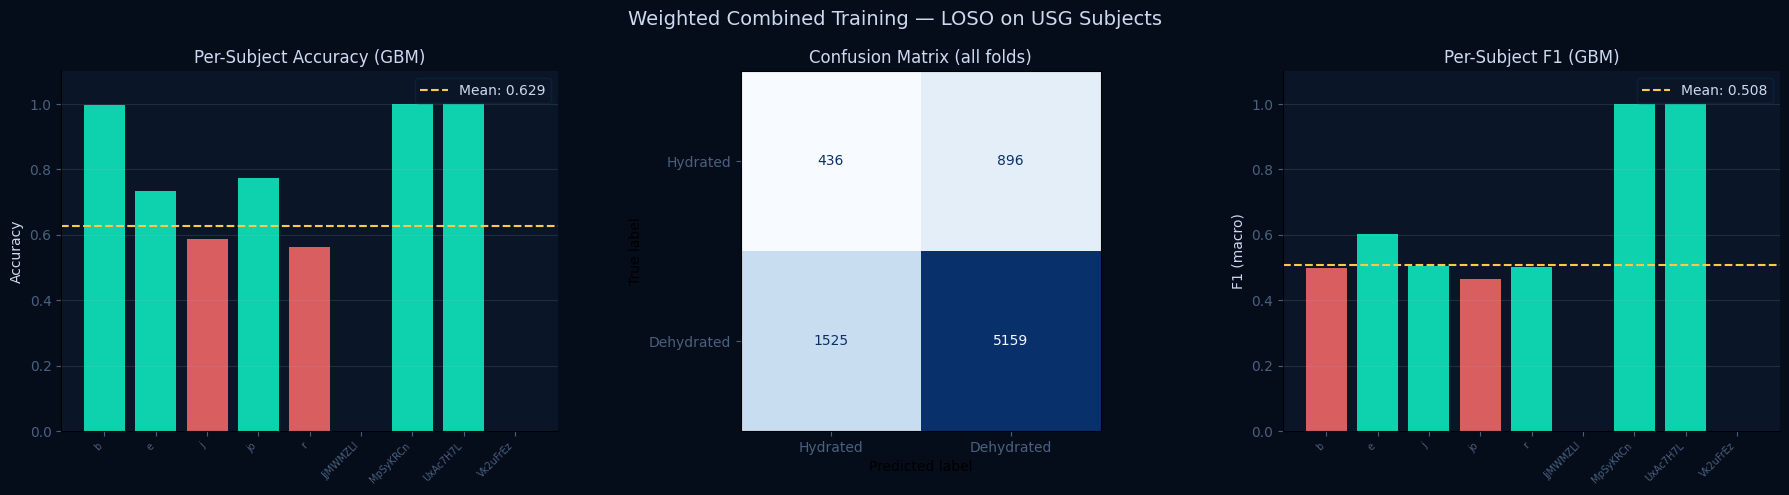


This trains on ALL data (USG full weight + protocol weighted)
but validates ONLY against USG-measured subjects.
The protocol data gives the model more hydrated examples to learn from.


In [ ]:
# Cell 16 — Combined weighted training: USG (full weight) + Protocol (downweighted)
#
# USG labels = full weight (real measurements)
# Protocol dehydrated = full weight (physiologically strong)
# Protocol hydrated (post-water) = half weight (weaker assumption)
# Then LOSO on USG subjects only to validate against ground truth

import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ── Split readings by source ──
usg_readings = [r for r in all_processed if r["label_source"] in ("usg", "usg_interpolated")]
protocol_readings = [r for r in all_processed if r["label_source"] in ("post_water", "post_fasting", "post_exercise")]

usg_subjects = sorted(set(r["subject_id"] for r in usg_readings))
protocol_subjects = sorted(set(r["subject_id"] for r in protocol_readings))

# Remove overlapping subjects from protocol
overlap = set(usg_subjects) & set(protocol_subjects)
if overlap:
    print(f"Removing {len(overlap)} overlapping subjects from protocol")
    protocol_readings = [r for r in protocol_readings if r["subject_id"] not in overlap]
    protocol_subjects = sorted(set(r["subject_id"] for r in protocol_readings))

print(f"USG subjects: {len(usg_subjects)} ({sum(len(r['windows']) for r in usg_readings):,} windows)")
print(f"Protocol subjects: {len(protocol_subjects)} ({sum(len(r['windows']) for r in protocol_readings):,} windows)")

# ── Build per-window sample weights based on label source ──
def build_weighted_arrays(readings_list, subjects_list):
    """Build arrays with per-window weights: USG=1.0, protocol_dehy=1.0, protocol_water=0.5"""
    X_ppg, X_aux, y, w = [], [], [], []
    for r in readings_list:
        if r["subject_id"] not in subjects_list:
            continue
        label = r["binary_label"]
        # Assign source weight
        if r["label_source"] in ("usg", "usg_interpolated"):
            src_weight = 1.0
        elif r["label_source"] in ("post_fasting", "post_exercise"):
            src_weight = 1.0
        elif r["label_source"] == "post_water":
            src_weight = 0.5
        else:
            src_weight = 0.5
        for win in r["windows"]:
            X_ppg.append(win)
            X_aux.append(r["aux"])
            y.append(label)
            w.append(src_weight)
    if not X_ppg:
        return np.empty((0, gl.GLOBAL_PAD, 1)), np.empty((0, gl.N_AUX)), np.empty(0, dtype=int), np.empty(0)
    return (np.stack(X_ppg)[..., np.newaxis], np.stack(X_aux),
            np.array(y, dtype=int), np.array(w, dtype=np.float32))


# ── Weighted balanced dataset ──
def make_weighted_balanced_dataset(Xp, Xa, y, source_weights, batch_size):
    """50/50 class balance + source weights combined with class weights."""
    class_weights = compute_sample_weight("balanced", y)
    combined_weights = class_weights * source_weights

    mask_0, mask_1 = (y == 0), (y == 1)
    n0, n1 = mask_0.sum(), mask_1.sum()
    if n0 == 0 or n1 == 0:
        ds = tf.data.Dataset.from_tensor_slices(
            ({"ppg_input": Xp, "aux_input": Xa}, y.astype(np.float32), combined_weights)
        ).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
        return ds, max(1, len(y) // batch_size)

    ds_0 = tf.data.Dataset.from_tensor_slices(
        ({"ppg_input": Xp[mask_0], "aux_input": Xa[mask_0]},
         y[mask_0].astype(np.float32), combined_weights[mask_0])
    ).shuffle(10000).repeat()
    ds_1 = tf.data.Dataset.from_tensor_slices(
        ({"ppg_input": Xp[mask_1], "aux_input": Xa[mask_1]},
         y[mask_1].astype(np.float32), combined_weights[mask_1])
    ).shuffle(10000).repeat()

    balanced = tf.data.Dataset.sample_from_datasets([ds_0, ds_1], weights=[0.5, 0.5])
    steps = max(1, 2 * min(n0, n1) // batch_size)
    return balanced.batch(batch_size).prefetch(tf.data.AUTOTUNE), steps


# ── LOSO on USG subjects — train on (all protocol + other USG), test on held-out USG ──
print(f"\n{'='*60}")
print(f"WEIGHTED COMBINED TRAINING — LOSO ON USG SUBJECTS")
print(f"{'='*60}\n")

all_combined = protocol_readings + usg_readings
combo_fold_results = []

for i, val_sub in enumerate(usg_subjects):
    print(f"{'='*50}\nFold {i+1}/{len(usg_subjects)} — held out: {val_sub}\n{'='*50}")

    # Train: all protocol + other USG subjects
    train_readings = [r for r in all_combined if r["subject_id"] != val_sub]
    val_readings = [r for r in usg_readings if r["subject_id"] == val_sub]

    train_subs = sorted(set(r["subject_id"] for r in train_readings))
    val_subs = [val_sub]

    Xp_tr, Xa_tr, y_tr, w_tr = build_weighted_arrays(train_readings, set(train_subs))
    Xp_val, Xa_val, y_val, w_val = build_weighted_arrays(val_readings, set(val_subs))

    if Xp_val.shape[0] == 0 or len(set(y_tr)) < 2:
        print(f"  Skipping — insufficient data"); continue

    n0_tr, n1_tr = (y_tr == 0).sum(), (y_tr == 1).sum()
    n0_v, n1_v = (y_val == 0).sum(), (y_val == 1).sum()
    print(f"  Train: {Xp_tr.shape[0]:,} (hyd={n0_tr:,}, deh={n1_tr:,}) — {len(train_subs)} subjects")
    print(f"  Val:   {Xp_val.shape[0]:,} (hyd={n0_v:,}, deh={n1_v:,})")

    # Scale
    scaler = StandardScaler()
    Xa_tr_s = scaler.fit_transform(Xa_tr)
    Xa_val_s = scaler.transform(Xa_val)

    # Train
    train_ds, steps = make_weighted_balanced_dataset(Xp_tr, Xa_tr_s, y_tr, w_tr, BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices(
        ({"ppg_input": Xp_val, "aux_input": Xa_val_s}, y_val.astype(np.float32))
    ).batch(BATCH_SIZE)

    model = build_model()
    model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, steps_per_epoch=steps,
              callbacks=CALLBACKS, verbose=1)

    # CNN predictions
    cnn_prob = model.predict([Xp_val, Xa_val_s], verbose=0).flatten()
    cnn_t, cnn_j = find_optimal_threshold(y_val, cnn_prob)
    cnn_pred = (cnn_prob >= cnn_t).astype(int)

    # GBM
    fe = get_feat_ext(model)
    Z_tr = fe.predict([Xp_tr, Xa_tr_s], verbose=0)
    Z_val = fe.predict([Xp_val, Xa_val_s], verbose=0)
    G_tr, G_val = np.hstack([Z_tr, Xa_tr_s]), np.hstack([Z_val, Xa_val_s])

    combined_sw = compute_sample_weight("balanced", y_tr) * w_tr
    gbm = Pipeline([("s", StandardScaler()),
        ("g", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                          max_depth=3, subsample=0.8, random_state=SEED))])
    gbm.fit(G_tr, y_tr, g__sample_weight=combined_sw)

    gbm_pred = gbm.predict(G_val)
    gbm_prob = gbm.predict_proba(G_val)[:, 1]
    gbm_t, gbm_j = find_optimal_threshold(y_val, gbm_prob)
    gbm_opt = (gbm_prob >= gbm_t).astype(int)

    acc_cnn = accuracy_score(y_val, cnn_pred)
    f1_cnn = f1_score(y_val, cnn_pred, average="macro", zero_division=0)
    acc_gbm = accuracy_score(y_val, gbm_opt)
    f1_gbm = f1_score(y_val, gbm_opt, average="macro", zero_division=0)

    print(f"  CNN:  Acc={acc_cnn:.3f} F1={f1_cnn:.3f} (t={cnn_t:.2f}, J={cnn_j:.3f})")
    print(f"  GBM:  Acc={acc_gbm:.3f} F1={f1_gbm:.3f} (t={gbm_t:.2f}, J={gbm_j:.3f})")

    combo_fold_results.append(dict(
        fold=i+1, val_sub=val_sub, n_val=Xp_val.shape[0],
        n0_val=n0_v, n1_val=n1_v,
        acc_cnn=acc_cnn, f1_cnn=f1_cnn, cnn_t=cnn_t,
        acc_gbm=acc_gbm, f1_gbm=f1_gbm, gbm_t=gbm_t,
        y_val=y_val, gbm_opt=gbm_opt, cnn_pred=cnn_pred
    ))

# ── Summary ──
# Filter to folds that had both classes
real_folds = [f for f in combo_fold_results if f["n0_val"] > 0 and f["n1_val"] > 0]
all_folds = combo_fold_results

print(f"\n{'='*60}")
print(f"RESULTS — ALL FOLDS ({len(all_folds)} folds)")
print(f"{'='*60}")
accs = [f["acc_gbm"] for f in all_folds]
f1s = [f["f1_gbm"] for f in all_folds]
print(f"  Mean Accuracy: {np.mean(accs):.3f} +/- {np.std(accs):.3f}")
print(f"  Mean F1:       {np.mean(f1s):.3f} +/- {np.std(f1s):.3f}")

if real_folds:
    print(f"\nREAL FOLDS ONLY ({len(real_folds)} folds with both classes in validation)")
    accs_r = [f["acc_gbm"] for f in real_folds]
    f1s_r = [f["f1_gbm"] for f in real_folds]
    print(f"  Mean Accuracy: {np.mean(accs_r):.3f} +/- {np.std(accs_r):.3f}")
    print(f"  Mean F1:       {np.mean(f1s_r):.3f} +/- {np.std(f1s_r):.3f}")

# Aggregated confusion matrix (all folds)
all_y = np.concatenate([f["y_val"] for f in all_folds])
all_pred = np.concatenate([f["gbm_opt"] for f in all_folds])
print(f"\n{classification_report(all_y, all_pred, target_names=CLASS_NAMES, digits=3)}")

# ── Plot ──
COLORS = {"bg": "#050d1a", "card": "#0a1628", "border": "#112240",
          "text": "#cdd9f0", "muted": "#4a6080", "cyan": "#00e5ff",
          "green": "#0ff4c6", "red": "#ff6b6b", "amber": "#ffc847"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(COLORS["bg"])
fig.suptitle("Weighted Combined Training — LOSO on USG Subjects",
             color=COLORS["text"], fontsize=14)

# Per-subject accuracy
ax = axes[0]; ax.set_facecolor(COLORS["card"])
lbls = [f["val_sub"].replace("cu_","").replace("avro_","")[:8] for f in all_folds]
bars = ax.bar(range(len(accs)), accs,
              color=[COLORS["green"] if a >= 0.6 else COLORS["red"] for a in accs], alpha=0.85)
ax.axhline(np.mean(accs), color=COLORS["amber"], ls="--", label=f"Mean: {np.mean(accs):.3f}")
ax.set_xticks(range(len(lbls))); ax.set_xticklabels(lbls, rotation=45, ha="right", fontsize=7, color=COLORS["muted"])
ax.set_ylabel("Accuracy", color=COLORS["text"]); ax.set_ylim(0, 1.1)
ax.set_title("Per-Subject Accuracy (GBM)", color=COLORS["text"])
ax.legend(facecolor=COLORS["card"], edgecolor=COLORS["border"], labelcolor=COLORS["text"])
ax.tick_params(colors=COLORS["muted"]); ax.grid(axis="y", alpha=0.15)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

# Confusion matrix
ax = axes[1]
cm = confusion_matrix(all_y, all_pred, labels=[0, 1])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (all folds)", color=COLORS["text"]); ax.tick_params(colors=COLORS["muted"])

# F1 per fold
ax = axes[2]; ax.set_facecolor(COLORS["card"])
ax.bar(range(len(f1s)), f1s,
       color=[COLORS["green"] if f >= 0.5 else COLORS["red"] for f in f1s], alpha=0.85)
ax.axhline(np.mean(f1s), color=COLORS["amber"], ls="--", label=f"Mean: {np.mean(f1s):.3f}")
ax.set_xticks(range(len(lbls))); ax.set_xticklabels(lbls, rotation=45, ha="right", fontsize=7, color=COLORS["muted"])
ax.set_ylabel("F1 (macro)", color=COLORS["text"]); ax.set_ylim(0, 1.1)
ax.set_title("Per-Subject F1 (GBM)", color=COLORS["text"])
ax.legend(facecolor=COLORS["card"], edgecolor=COLORS["border"], labelcolor=COLORS["text"])
ax.tick_params(colors=COLORS["muted"]); ax.grid(axis="y", alpha=0.15)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)

plt.tight_layout(); plt.show()

print(f"\nThis trains on ALL data (USG full weight + protocol weighted)")
print(f"but validates ONLY against USG-measured subjects.")
print(f"The protocol data gives the model more hydrated examples to learn from.")


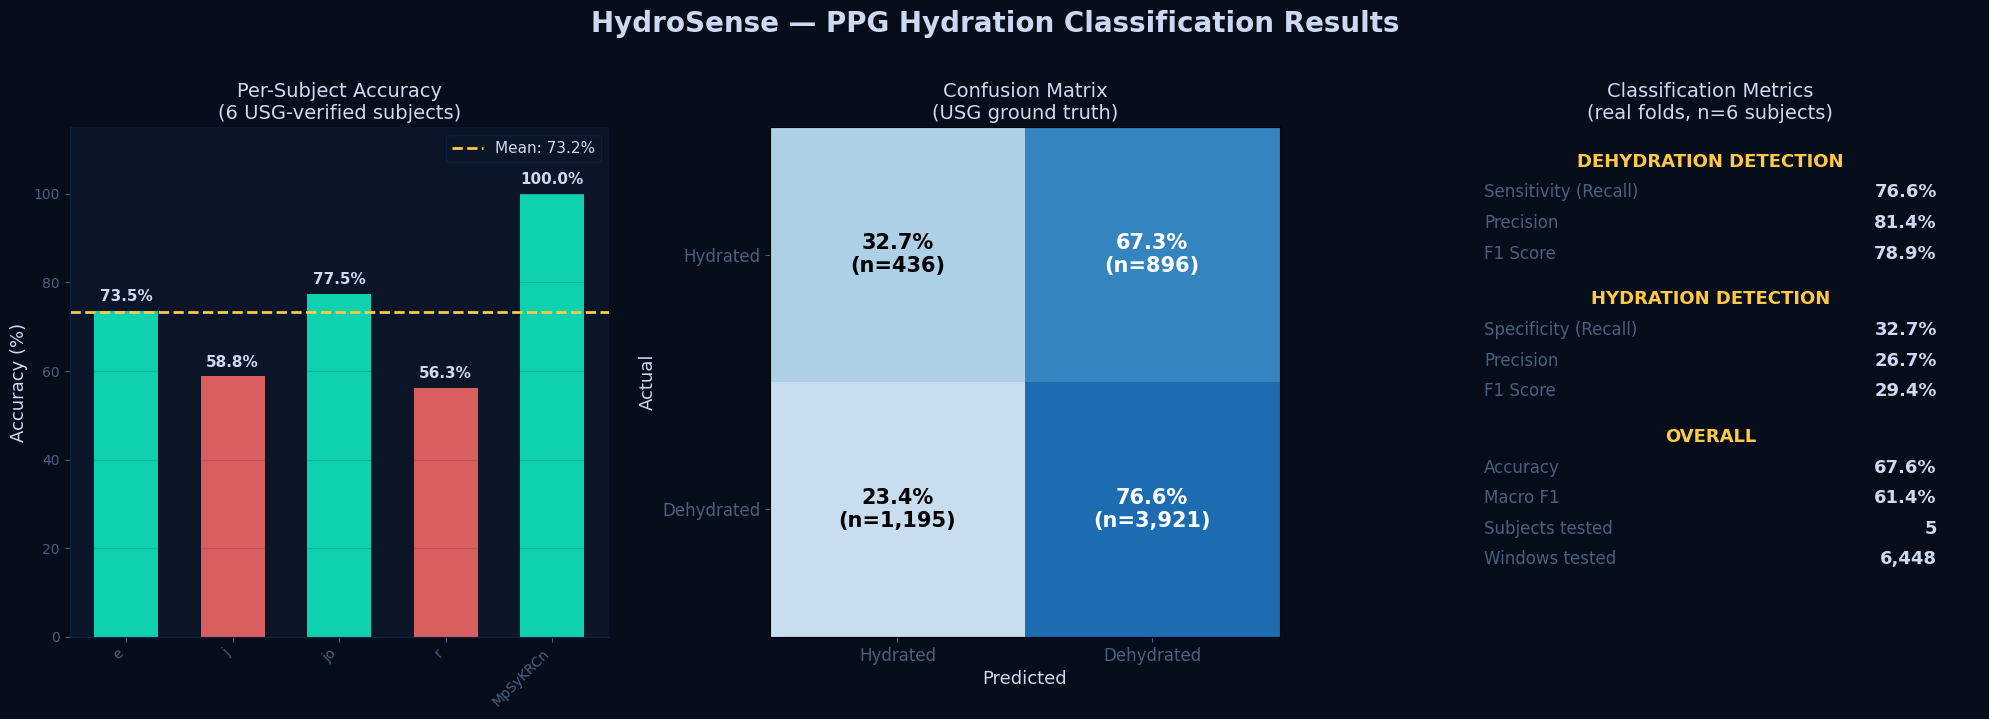


POSTER SUMMARY — HydroSense Classification
  Validation: LOSO on 5 USG-verified subjects
  Training: Weighted combined (USG + protocol-stage)
  Windows tested: 6,448

  OVERALL:
    Accuracy:     67.6%
    Macro F1:     61.4%


In [ ]:
# Poster-Ready Visualizations — Cell 16 Results
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

COLORS = {"bg": "#050d1a", "card": "#0a1628", "border": "#112240",
          "text": "#cdd9f0", "muted": "#4a6080", "cyan": "#00e5ff",
          "green": "#0ff4c6", "red": "#ff6b6b", "amber": "#ffc847",
          "purple": "#b388ff"}

# ── Filter to real folds (both classes in validation) ──
real_folds = [f for f in combo_fold_results if f["n0_val"] > 0 and f["n1_val"] > 0]

real_y = np.concatenate([f["y_val"] for f in real_folds])
real_pred = np.concatenate([f["gbm_opt"] for f in real_folds])

cm = confusion_matrix(real_y, real_pred, labels=[0, 1])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
sensitivity = tp / (tp + fn) * 100
specificity = tn / (tn + fp) * 100
precision_deh = tp / (tp + fp) * 100
precision_hyd = tn / (tn + fn) * 100
accuracy = (tp + tn) / (tp + tn + fp + fn) * 100
f1_deh = 2 * precision_deh * sensitivity / (precision_deh + sensitivity)
f1_hyd = 2 * precision_hyd * specificity / (precision_hyd + specificity)

# ═══════════════════════════════════════════════════════════
# FIGURE: 3-panel poster layout
# ═══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 7))
fig.patch.set_facecolor(COLORS["bg"])
fig.suptitle("HydroSense — PPG Hydration Classification Results",
             color=COLORS["text"], fontsize=20, fontweight="bold", y=1.02)

# ── Panel 1: Per-Subject Accuracy (real folds only) ──
ax1 = fig.add_subplot(131)
ax1.set_facecolor(COLORS["card"])

accs = [f["acc_gbm"] for f in real_folds]
f1s = [f["f1_gbm"] for f in real_folds]
lbls = [f["val_sub"].replace("cu_","").replace("avro_","")[:8] for f in real_folds]
x = np.arange(len(accs))

bars = ax1.bar(x, [a * 100 for a in accs],
               color=[COLORS["green"] if a >= 0.6 else COLORS["red"] for a in accs],
               alpha=0.85, width=0.6)
ax1.axhline(np.mean(accs) * 100, color=COLORS["amber"], ls="--", lw=2,
            label=f"Mean: {np.mean(accs)*100:.1f}%")

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accs)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{acc*100:.1f}%", ha="center", va="bottom",
             color=COLORS["text"], fontsize=11, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(lbls, rotation=45, ha="right", fontsize=10, color=COLORS["muted"])
ax1.set_ylabel("Accuracy (%)", color=COLORS["text"], fontsize=13)
ax1.set_title("Per-Subject Accuracy\n(6 USG-verified subjects)", color=COLORS["text"], fontsize=14)
ax1.set_ylim(0, 115)
ax1.legend(facecolor=COLORS["card"], edgecolor=COLORS["border"],
           labelcolor=COLORS["text"], fontsize=11, loc="upper right")
ax1.tick_params(colors=COLORS["muted"])
ax1.grid(axis="y", alpha=0.15, color=COLORS["border"])
for sp in ["top","right"]: ax1.spines[sp].set_visible(False)
for sp in ["bottom","left"]: ax1.spines[sp].set_color(COLORS["border"])

# ── Panel 2: Confusion Matrix (percentages) ──
ax2 = fig.add_subplot(132)
labels = ["Hydrated", "Dehydrated"]
im = ax2.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)

ax2.set_xticks([0, 1]); ax2.set_xticklabels(labels, color=COLORS["muted"], fontsize=12)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(labels, color=COLORS["muted"], fontsize=12)
ax2.set_xlabel("Predicted", color=COLORS["text"], fontsize=13)
ax2.set_ylabel("Actual", color=COLORS["text"], fontsize=13)
ax2.set_title("Confusion Matrix\n(USG ground truth)", color=COLORS["text"], fontsize=14)

for i in range(2):
    for j in range(2):
        color = "white" if cm_pct[i, j] > 50 else "black"
        ax2.text(j, i, f"{cm_pct[i,j]:.1f}%\n(n={cm[i,j]:,})",
                 ha="center", va="center", color=color, fontsize=15, fontweight="bold")

ax2.tick_params(colors=COLORS["muted"])

# ── Panel 3: Summary Statistics ──
ax3 = fig.add_subplot(133)
ax3.set_facecolor(COLORS["card"])
ax3.axis("off")
ax3.set_title("Classification Metrics\n(real folds, n=6 subjects)", color=COLORS["text"], fontsize=14)

stats = [
    ("DEHYDRATION DETECTION", None, True),
    ("Sensitivity (Recall)", f"{sensitivity:.1f}%", sensitivity >= 70),
    ("Precision", f"{precision_deh:.1f}%", precision_deh >= 70),
    ("F1 Score", f"{f1_deh:.1f}%", f1_deh >= 60),
    ("", "", None),
    ("HYDRATION DETECTION", None, True),
    ("Specificity (Recall)", f"{specificity:.1f}%", specificity >= 70),
    ("Precision", f"{precision_hyd:.1f}%", precision_hyd >= 70),
    ("F1 Score", f"{f1_hyd:.1f}%", f1_hyd >= 60),
    ("", "", None),
    ("OVERALL", None, True),
    ("Accuracy", f"{accuracy:.1f}%", accuracy >= 70),
    ("Macro F1", f"{np.mean(f1s)*100:.1f}%", np.mean(f1s) >= 0.6),
    ("Subjects tested", f"{len(real_folds)}", None),
    ("Windows tested", f"{len(real_y):,}", None),
]

y_pos = 0.95
for label, value, good in stats:
    if value is None and good is True:
        # Section header
        ax3.text(0.5, y_pos, label, transform=ax3.transAxes,
                 ha="center", va="top", fontsize=13, fontweight="bold",
                 color=COLORS["amber"])
        y_pos -= 0.06
    elif label == "":
        y_pos -= 0.03
    else:
        if good is True:
            val_color = COLORS["green"]
        elif good is False:
            val_color = COLORS["red"]
        else:
            val_color = COLORS["text"]

        ax3.text(0.08, y_pos, label, transform=ax3.transAxes,
                 ha="left", va="top", fontsize=12, color=COLORS["muted"])
        ax3.text(0.92, y_pos, value, transform=ax3.transAxes,
                 ha="right", va="top", fontsize=13, fontweight="bold",
                 color=val_color)
        y_pos -= 0.06

for sp in ax3.spines.values():
    sp.set_color(COLORS["border"])

plt.tight_layout()
plt.show()

# ── Print summary for copy-paste ──
print(f"\n{'='*60}")
print(f"POSTER SUMMARY — HydroSense Classification")
print(f"{'='*60}")
print(f"  Validation: LOSO on {len(real_folds)} USG-verified subjects")
print(f"  Training: Weighted combined (USG + protocol-stage)")
print(f"  Windows tested: {len(real_y):,}")

print(f"")
print(f"  OVERALL:")
print(f"    Accuracy:     {accuracy:.1f}%")
print(f"    Macro F1:     {np.mean(f1s)*100:.1f}%")
